In [2]:
%load_ext autoreload
%autoreload 2

import os
import util
import math
import logging
import functools

import numpy as np
import pandas as pd  
import matplotlib.pyplot as plt

import exp_quals
import pylupnt as pnt
import pathfinder_data
import plotting as plotting
from problem import Request, ServiceWindow, PntSchedulingProblem, reset_id_counters
from util import timed, get_metrics


figures_path = "../figures/quals/"
cache_path = "cache/quals/"

logging.basicConfig(level=logging.INFO)
# Backend for matplotlib (inline, TkAgg, Qt5Agg, WXAgg, GTKAgg, Agg, ps, pdf, svg, cairo, Macosx, WebAgg, nbAgg, template)
%matplotlib widget

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
date = "2022-01-15T00:00:00"
duration_factor = 0.4

In [4]:
# *******************************************************************************
# Satellite constellation
# *******************************************************************************
orbital_elements = pathfinder_data.orbital_elements.copy()
users = pathfinder_data.users.copy()
N_sat = 6
N_planes = 3
N_sat_plane = N_sat // N_planes

# Classical orbital elements (a, e, i, W, w, M) [km, -, rad, rad, rad, rad]
sma = 6142.4  # [km] Semi-major axis
ecc = [0.001, 0.6, 0.6]  # [-] Eccentricity
inc = np.deg2rad([0.001, 57.7, 57.7])  # [rad] Inclination
raan = np.deg2rad([0, -90, 0])  # [rad] Right ascension of the ascending node
aop = np.deg2rad([-45, -90, 90])  # [rad] Argument of periapsis
ma = np.deg2rad([0, 180])  # [rad] Mean anomaly

# Epoch (TAI)
epoch_0 = pnt.SpiceInterface.string_to_tai(date)

coe_mi = np.zeros((N_sat, 6))
for i_pl in range(N_planes):
    for i_spl in range(N_sat_plane):
        i_sat = i_pl * N_sat_plane + i_spl
        coe_mi[i_sat] = np.array(
            [sma, ecc[i_pl], inc[i_pl], raan[i_pl], aop[i_pl], ma[i_spl]]
        )

rv0_moon_sat_mi = pnt.classical_to_cartesian(coe_mi, pnt.MU_MOON)
# rv0_moon_sat_mi = pnt.FrameConverter.convert(
#     epoch_0, rv0_moon_sat_OP,pnt.MOON_OP, pnt.MOON_CI
# )

# Time
sma = coe_mi[0, 0]  # [km] Semi-major axis
period = 2 * np.pi * np.sqrt(np.power(sma, 3) / pnt.MU_MOON)  # [s] Orbital period
Dt = 5 * pnt.SECS_PER_MINUTE  # [s] Simulation time step
dt = 5 * pnt.SECS_PER_MINUTE  # [s] Propagation time step
N_days = 3  # [-] Number of days
tf = N_days * pnt.SECS_PER_DAY  # [s] Simulation final time
N_t = int(tf / Dt)  # [-] Number of time steps
tspan = np.linspace(0, tf, N_t)  # [s] Time since first epoch
epochs = epoch_0 + tspan  # [s] Epochs (TAI)

# Dynamics (three-body)
dynamics = pnt.NBodyDynamics()
dynamics.set_primary_body(pnt.Body.Moon())
dynamics.add_body(pnt.Body.Earth())
dynamics.set_time_step(dt)

# Propagation
# rv_{from}_{to}_{frame} [km, km/s] (x, y, z, vx, vy, vz)
rv_moon_sat_mi = np.zeros((N_sat, N_t, 6))
rv_moon_sat_pa = np.zeros((N_sat, N_t, 6))
for i_sat in range(N_sat):
    rv_moon_sat_mi[i_sat] = dynamics.propagate(rv0_moon_sat_mi[i_sat], epoch_0, epochs)
    rv_moon_sat_pa[i_sat] = pnt.FrameConverter.convert(
        epochs, rv_moon_sat_mi[i_sat], pnt.MOON_CI, pnt.MOON_PA
    )
rv_moon_earth_mi = pnt.SpiceInterface.get_body_pos_vel(epochs, pnt.MOON, pnt.EARTH)
rv_moon_earth_pa = pnt.FrameConverter.convert(epochs, rv_moon_earth_mi, pnt.MOON_CI, pnt.MOON_PA)
rv_moon_sun_mi = pnt.SpiceInterface.get_body_pos_vel(epochs, pnt.MOON, pnt.SUN)
rv_moon_sun_pa = pnt.FrameConverter.convert(epochs, rv_moon_sun_mi, pnt.MOON_CI, pnt.MOON_PA)

# Attitude
r_sun = rv_moon_sun_mi[None, :, 0:3] - rv_moon_sat_mi[:, :, 0:3]
r_earth = rv_moon_earth_mi[None, :, 0:3] - rv_moon_sat_mi[:, :, 0:3]

e_sun = r_sun / np.linalg.norm(r_sun, axis=2)[:, :, None]
e_earth = r_earth / np.linalg.norm(r_earth, axis=2)[:, :, None]

r = rv_moon_sat_mi[:, :, 0:3]
v = rv_moon_sat_mi[:, :, 3:6]
r_norm = r / np.linalg.norm(r, axis=2)[:, :, None]
v_norm = v / np.linalg.norm(v, axis=2)[:, :, None]
e_nadir = -r_norm

# Yaw-Steering (YS)
ez_ys = -r_norm
ey_ys = util.cross_norm(e_nadir, e_sun)
ex_ys = util.cross_norm(ey_ys, ez_ys)

# Sun angle
sun_angle_cos = np.sum(e_sun * ex_ys, axis=2)
sun_angle = np.arccos(sun_angle_cos)

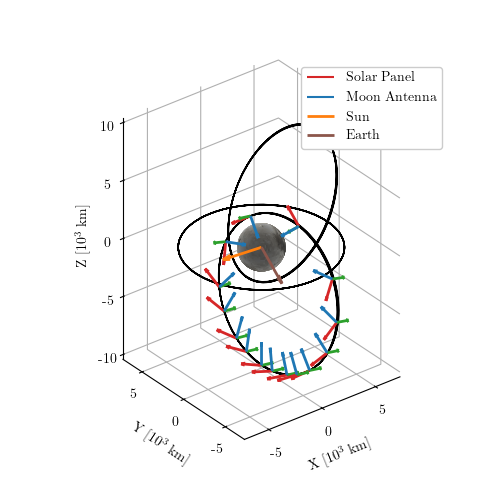

In [7]:
# Attitude
fig = pnt.plot.Plot3D(figsize=(5, 5), elev=31, azim=-128)
fig.plot_surface(pnt.MOON, scale=3)


e_moon_sun = rv_moon_sun_mi[0, 0:3] / np.linalg.norm(rv_moon_sun_mi[0, 0:3])
e_moon_earth = rv_moon_earth_mi[0, 0:3] / np.linalg.norm(rv_moon_earth_mi[0, 0:3])

for i_sat in (0, 2, 4):
    plt.plot(
        rv_moon_sat_mi[i_sat, :, 0],
        rv_moon_sat_mi[i_sat, :, 1],
        rv_moon_sat_mi[i_sat, :, 2],
        color="black",
        linewidth=1,
    )

i_sat = 4
# Yaw-Steering Frame
scale = pnt.R_MOON
for i in range(0, int(N_t / 4), 15):
    r_ys = rv_moon_sat_mi[i_sat, i, 0:3]
    plt.quiver(
        *r_ys,
        *ex_ys[i_sat, i] * scale,
        color="tab:red",
        arrow_length_ratio=0.2,
        linewidth=2,
    )
    plt.quiver(
        *r_ys,
        *ey_ys[i_sat, i] * scale,
        color="tab:green",
        arrow_length_ratio=0.2,
        linewidth=2,
    )
    plt.quiver(
        *r_ys,
        *ez_ys[i_sat, i] * scale,
        color="tab:blue",
        arrow_length_ratio=0.2,
        linewidth=2,
    )
# plt.quiver([], [], [], [], [], [], color="tab:red", label="$\\mathbf{e}_x$ (Solar Panel)")
plt.quiver([], [], [], [], [], [], color="tab:red", label="Solar Panel")
# plt.quiver([], [], [], [], [], [], color="tab:green", label="$\\mathbf{e}_y$ (Earth Antenna)")
# plt.quiver([], [], [], [], [], [], color="tab:blue", label="$\\mathbf{e}_z$ (Moon Antenna)")
plt.quiver([], [], [], [], [], [], color="tab:blue", label="Moon Antenna")


scale = 2 * pnt.R_MOON
o = np.zeros(3)
d = e_moon_sun * scale
plt.quiver(*o, *d, arrow_length_ratio=0.2, linewidth=2, color="tab:orange", label="Sun")
d = e_moon_earth * scale
plt.quiver(
    *o, *d, linewidth=2, arrow_length_ratio=0.2, color="tab:brown", label="Earth"
)

fig.set_tickpad(0)
fig.set_tick_multiplier(1e-3)
fig.set_labels("X [$10^3$ km]", "Y [$10^3$ km]", "Z [$10^3$ km]")
fig.set_pane_color([1, 1, 1])
fig.set_labelpad(0, 0, 0)
r, h = 7e3, 10e3
fig.set_lims([-r, r], [-r, r], [-h, h])
plt.legend(facecolor="white", framealpha=1, loc="upper right")

plt.savefig(os.path.join(figures_path, "satellite_attitude.pdf"))
plt.show()

In [8]:
# *******************************************************************************
# Users
# *******************************************************************************


def propagate_orbital_user(user: dict) -> np.array:
    """
    Propagate a user on orbit around the Moon.
    :param coe: [a, e, i, W, w, M] [km, -, deg, deg, deg, deg]
    :param frame: Frame
    :return: [x, y, z, vx, vy, vz] [km, km/s]
    """
    coe = user["orbital_elements"].copy()
    frame = user["frame"]
    coe[2:] = np.deg2rad(coe[2:])
    rv0 = pnt.classical_to_cartesian(coe, pnt.MU_MOON)
    rv0_mi = pnt.FrameConverter.convert(epoch_0, rv0, frame, pnt.MOON_CI)
    rv_mi = dynamics.propagate(rv0_mi, epoch_0, epochs)
    return rv_mi


def propagate_surface_user(user: dict) -> np.array:
    """
    Propagate a user on the surface of the Moon.
    :param lat_lon_alt: [lat, lon, alt] [deg, deg, km]
    :return: [x, y, z, vx, vy, vz] [km, km/s]
    """
    lat_lon_alt = user["location"].copy()
    lat_lon_alt[:2] = np.deg2rad(lat_lon_alt[:2])
    rv_pa = np.zeros((N_t, 6))
    rv_pa[:, :3] = pnt.geographical_to_cartesian(lat_lon_alt, pnt.R_MOON)
    return rv_pa


# Users
N_users = len(users)
user_type = np.array([user["type"] for user in users])
rv_moon_user_mi = np.zeros((N_users, N_t, 6))
rv_moon_user_pa = np.zeros((N_users, N_t, 6))
az_el_rho = np.zeros((N_sat, N_users, N_t, 3))

for i_usr, user in enumerate(users):
    if user["type"] == "orbital":
        rv_moon_user_mi[i_usr] = propagate_orbital_user(user)
        rv_moon_user_pa[i_usr] = pnt.FrameConverter.convert(
            epochs, rv_moon_user_mi[i_usr], pnt.MOON_CI, pnt.MOON_PA
        )
    elif user["type"] == "surface":
        rv_moon_user_pa[i_usr] = propagate_surface_user(user)
        rv_moon_user_mi[i_usr] = pnt.FrameConverter.convert(
            epochs, rv_moon_user_pa[i_usr], pnt.MOON_PA, pnt.MOON_CI
        )
    else:
        raise ValueError("Invalid user type")

    for j_sat in range(N_sat):
        az_el_rho[j_sat, i_usr] = pnt.cartesian_to_azimuth_elevation_range(
            rv_moon_user_mi[i_usr, :, :3], rv_moon_sat_mi[j_sat, :, :3]
        )

# Elevation mask
surface_elev_mask = np.deg2rad(15)  # [rad] Elevation mask
orbital_elev_mask = np.deg2rad(0)  # [rad] Elevation mask
max_elevation = np.max(az_el_rho[:, :, :, 1], axis=2)
# min_elevation = np.maximum(surface_elev_mask, max_elevation - np.deg2rad(90))
min_elevation = np.ones_like(max_elevation) * surface_elev_mask
min_elevation[:, user_type == "orbital"] = orbital_elev_mask
min_elevation[:, -1] = 0  # North Pole
user_visible = np.greater_equal(az_el_rho[:, :, :, 1], min_elevation[:, :, None])

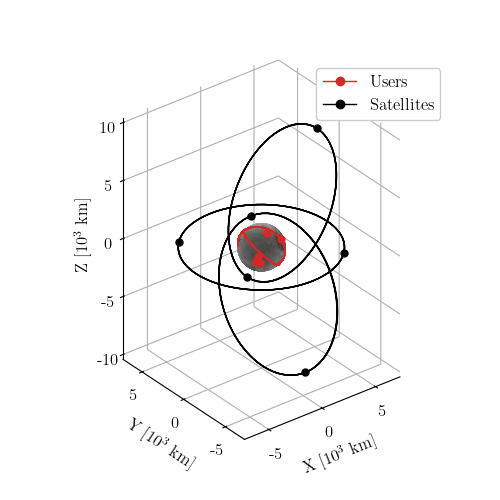

In [10]:
t = N_t // N_days
plt.rcParams.update({"font.size": 12})
plotting.plot_satellites_users(
    rv_moon_sat_mi[:, :t],
    rv_moon_user_mi[:, :t],
    rv_moon_earth_mi[:, :t],
    rv_moon_sun_mi[:, :t],
    user_type,
)
plt.savefig(os.path.join(figures_path, "satellite_users.pdf"))
plt.show()

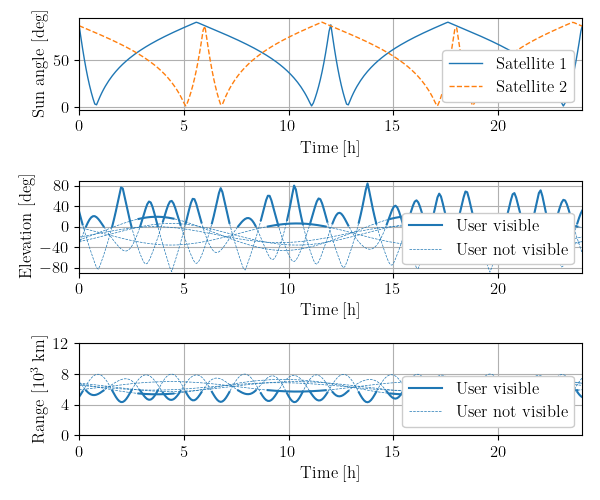

In [11]:
fig, axs = plt.subplots(3, 1, figsize=(6, 5))
# Sun pointing
plt.sca(axs[0])
sun_angle_cos = np.sum(e_sun * ex_ys, axis=2)
sun_angle = np.arccos(sun_angle_cos)
x = tspan / pnt.SECS_PER_HOUR
y = 90 - np.rad2deg(sun_angle)
plt.plot(x, y[4], label="Satellite 1", color="tab:blue", lw=1)
plt.plot(x, y[5], label="Satellite 2", color="tab:orange", linestyle="--", lw=1)

plt.ylabel("Sun angle [deg]")
plt.xlim([0, 24])
# plt.ylim([50, 90])
# plt.yticks(np.arange(50, 90 + 1, 10))
plt.xlabel("Time [h]")
plt.grid()
plt.legend(facecolor="white", framealpha=1, loc="lower right")
plt.tight_layout()

plotting.plot_elevation_range(tspan, az_el_rho[0], user_visible[0], axs=axs[1:])
axs[1].set_ylim([-90, 90])
axs[1].set_yticks(np.arange(-80, 80 + 1, 40))
axs[1].set_xlim([0, 24])
axs[2].set_ylim([0, 11])
axs[2].set_yticks(np.arange(0, 13, 4))
axs[2].set_xlim([0, 24])
plt.xlim([0, 24])
plt.tight_layout()
plt.savefig(os.path.join(figures_path, "satellite_sun_elevation_range.pdf"))
plt.show()

In [12]:
# *******************************************************************************
# Contacts
# *******************************************************************************

# Navigation signal
fs = 2492.028e6  # Carrier frequency [Hz]
fc = 5.115e6  # Spread code frequency [Hz]
Tc = 1 / fc  # Spread code period [s]

# Receiver parameters
NF_lna = 1  # LNA noise figure [dB]
T_sys = 113  # System noise temperature [K]
B_dll = 0.5  # DLL bandwidth [Hz]
d = 1.0  # Early-late spacing [chips]
T_i = 0.02  # Coherent integration time [s]
B_fe = 2 * fc  # Front-end bandwidth [Hz]

# Constants
c = 2.998e8  # Speed of light [m/s]
k = -228.6  # Boltzmann constant [dBW/Hz/K]

# Link budget
rv_user_sat_mi = rv_moon_user_mi[None, :, :, :] - rv_moon_sat_mi[:, None, :, :]
r = np.linalg.norm(rv_user_sat_mi[:, :, :, :3], axis=3)
r[~user_visible] = np.nan
# r = 8e6 # Distance [m]
EIRP = 30  # Equivalent isotropic radiated power [dBW]
L_fs = np.zeros_like(r)  # Free space loss [dB]
for i_sat in range(N_sat):
    L_fs[i_sat] = pnt.decimal2dB(
        (4 * np.pi * r[i_sat] * fs / c) ** 2
    )  # Free space loss [dB]
L_fs = 10 * np.log10((4 * np.pi * r * fs / c) ** 2)  # Free space loss [dB]
Pr = EIRP - L_fs  # Received power [dBW]

# Antenna gain
T_atm = 290  # Atmospheric noise temperature [K]
T_eq = 10 * np.log10(
    T_sys + T_atm * (10 ** (NF_lna / 10) - 1)
)  # Equivalent noise temperature [dBK]

mu = 0.6  # Antenna efficiency
D_ant = 0.3  # Antenna diameter [m]
# Maximum antenna gain [dBi]
Gr_max = pnt.decimal2dB(mu * (np.pi * D_ant * fs / c) ** 2)
Gr_max = 6

theta = 0  # Beamwidth [deg]
theta_3dB = 40  # 3 dB beamwidth [deg]
Gr = pnt.decimal2dB(pnt.dB2decimal(Gr_max) - 12 * (theta / theta_3dB) ** 2)  # [dBi]

# Gain-to-noise temperature [dB]
GT = Gr - T_eq
# GT = -20
CN0 = Pr - k + GT  # Carrier-to-noise density ratio [dB-Hz]

/var/folders/m9/t0lwgrj15w37pjv7jdy9m0g40000gp/T/ipykernel_49061/3586966227.py:21: RuntimeWarning: All-NaN slice encountered
  CN0_norm /= np.nanmax(CN0_norm, axis=1)[:, None]
/var/folders/m9/t0lwgrj15w37pjv7jdy9m0g40000gp/T/ipykernel_49061/3586966227.py:30: RuntimeWarning: All-NaN slice encountered
  CN0_norm /= np.nanmax(CN0_norm, axis=1)[:, None]


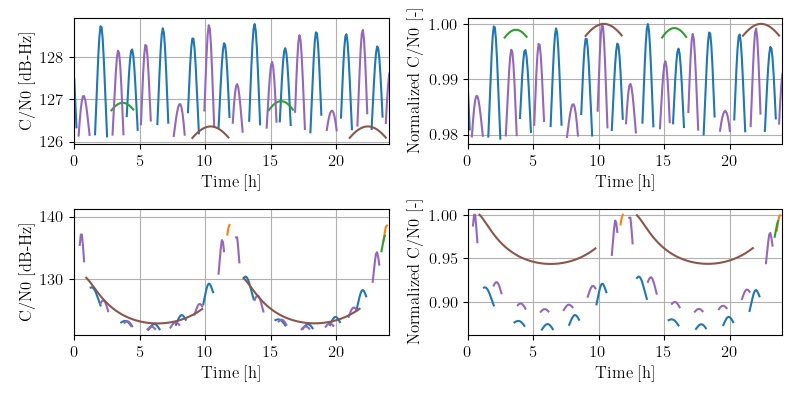

In [13]:
fig, ax = plt.subplots(2, 2, figsize=(8, 4))
t = N_t // N_days
xlim = [0, 24]
x = tspan / pnt.SECS_PER_HOUR
plt.sca(ax[0,0])
plt.plot(x, CN0[0].T)
plt.xlabel("Time [h]")
plt.ylabel("C/N0 [dB-Hz]")
plt.xlim(xlim)
plt.grid()

plt.sca(ax[1,0])
plt.plot(x, CN0[2].T)
plt.xlabel("Time [h]")
plt.ylabel("C/N0 [dB-Hz]")
plt.xlim(xlim)
plt.grid()

plt.sca(ax[0,1])
CN0_norm = CN0[0].copy()
CN0_norm /= np.nanmax(CN0_norm, axis=1)[:, None]
plt.plot(x, CN0_norm.T)
plt.xlabel("Time [h]")
plt.ylabel("Normalized C/N0 [-]")
plt.xlim(xlim)
plt.grid()

plt.sca(ax[1,1])
CN0_norm = CN0[2].copy()
CN0_norm /= np.nanmax(CN0_norm, axis=1)[:, None]
plt.plot(x, CN0_norm.T)
plt.xlabel("Time [h]")
plt.ylabel("Normalized C/N0 [-]")
plt.xlim(xlim)
plt.grid()

plt.tight_layout()
plt.show()

In [14]:
# *******************************************************************************
# Problem
# *******************************************************************************

duration_factor = 4.0
# Contact durations
contact_durations = list[np.array]([] for _ in range(N_sat))
contact_start_ends = list[np.array]([] for _ in range(N_sat))
for i_sat in range(N_sat):
    for i, user in enumerate(users):
        starts, ends = util.get_start_end_indexes(user_visible[i_sat, i])
        contact_start_ends[i_sat].append(np.vstack((starts, ends)).T)
        contact_durations[i_sat].append((ends - starts) * Dt / pnt.SECS_PER_MINUTE)
total_contact_durations = np.array(
    [[x.sum() for x in contact_durations[i_sat]] for i_sat in range(N_sat)]
)
contact_durations_pathfinder = np.array([user["contact"] for user in users])
contact_durations_pathfinder = total_contact_durations[0] * duration_factor
contact_durations_pathfinder = np.round(contact_durations_pathfinder / 60 * 2) * 60 / 2
logging.debug(
    "Contact durations [minutes]",
    np.round(total_contact_durations / 60, 1),
    contact_durations_pathfinder / 60,
)


reset_id_counters()

# Requests
requests = list[Request]()
for j_day in range(N_days):
    for i, user in enumerate(users):
        dur = contact_durations_pathfinder[i] / 2 / 60
        requests.append(
            Request(usr_id=user["id"], ts=j_day * 24, te=N_days * 24, dur=dur)
        )
N_req = len(requests)

# Service windows
service_windows = list[ServiceWindow]()
for i_sat in range(N_sat):
    for request in requests[1:]:
        for start, end in contact_start_ends[i_sat][request.usr_id]:
            # Convert indexes to hours
            start_h = start * Dt / pnt.SECS_PER_HOUR
            end_h = end * Dt / pnt.SECS_PER_HOUR

            if end_h <= request.ts or start_h >= request.te:
                continue

            ts = math.floor(max(start_h, request.ts))
            te = math.ceil(min(end_h, request.te))
            service_windows.append(
                ServiceWindow(sat_id=i_sat, usr_id=request.usr_id, ts=ts, te=te)
            )
N_win = len(service_windows)

# Transition times
transition_times = np.ones((N_sat, N_win, N_win))
transition_times *= 0.2  # hours
for i_sat in range(N_sat):
    np.fill_diagonal(transition_times[i_sat, :, :], 0)
    transition_times[i_sat, 0, :] = 0
    transition_times[i_sat, :, 0] = 0

# Energy and data generation functions
S_panels = 3 * 0.5 * 0.8  # [m^2] Solar panels area
I_earth = 1361  # [W/m^2] Solar irradiance
efficiency = 0.2  # Solar panels efficiency
P_solar_max = round(S_panels * I_earth * efficiency)  # [W] Max power generation
P_solar_max = 50  # [W] Max power generation
R_dte_max = -2e3  # [kbps] Direct-To-Earth max data rate

payload_data_gen = -1.9 * R_dte_max  # [kbps] Payload data generation
payload_energy_gen = -1.9 * P_solar_max  # [W] Payload power generation

max_energy = np.abs(P_solar_max) * 12  # [Wh] Max energy capacity
min_energy = max_energy * 0.2  # [Wh] Min energy capacity
max_data = np.abs(R_dte_max) * 12  # [Mb] Max data capacity
min_data = max_data * 0.2  # [Mb] Min data capacity

energy_gen = P_solar_max * sun_angle_cos * pnt.SECS_PER_HOUR
data_gen = R_dte_max * pnt.SECS_PER_HOUR * np.ones_like(energy_gen)

# Problem
problem = PntSchedulingProblem(
    t_step=Dt / pnt.SECS_PER_HOUR,
    t_final=tf / pnt.SECS_PER_HOUR,
    requests=requests,
    service_windows=service_windows,
    transition_times=transition_times,
    CN0=CN0,
    max_energy=max_energy,
    min_energy=min_energy,
    max_data=max_data,
    min_data=min_data,
    payload_data_gen=payload_data_gen,
    payload_energy_gen=payload_energy_gen,
    energy_gen=energy_gen,
    data_gen=data_gen,
)

/Users/guillemcv/Development/NavLab/LuPNT/examples/projects/pnt-scheduling/python/problem.py:173: RuntimeWarning: All-NaN slice encountered
  self.CN0_norm = self.CN0 / np.nanmax(self.CN0, axis=2)[:, :, None]


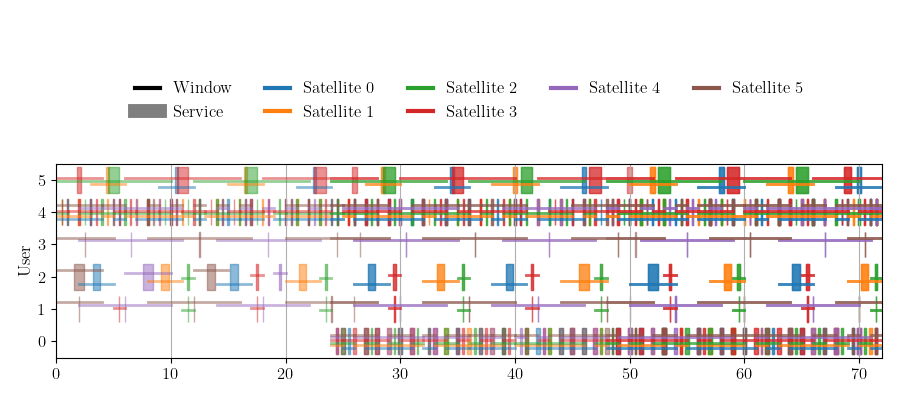

In [15]:
fig, ax = plt.subplots(1, 1, figsize=(9, 4))
plotting.plot_requests_service_windows(requests, service_windows, ax=ax)
# plt.xlim([12, 36])
plt.tight_layout()

In [16]:
from solvers import RuleBasedSolver
s0 = problem.initial_state()
solver = RuleBasedSolver(problem)
policy = solver.solve(s0, N_max=5, dur_min=1.0)
policy, time = timed(solver.solve, s0, N_max=5, dur_min=1.0)

In [17]:
metric = get_metrics(problem, policy, time, gamma=1)
print(metric)

{'total': 59.683, 'user': [100.0, nan, 100.0, nan, 100.0, 100.0, 61.674, nan, 53.0612, nan, 92.4528, 100.0, 0.0, nan, 0.0, nan, 0.0, 5.8824], 'reward': 31.1388, 'time': 3.92972}


/Users/guillemcv/Development/NavLab/LuPNT/examples/projects/pnt-scheduling/python/problem.py:700: RuntimeWarning: invalid value encountered in scalar divide
  sf.req_times[req.id] / req.dur * 100


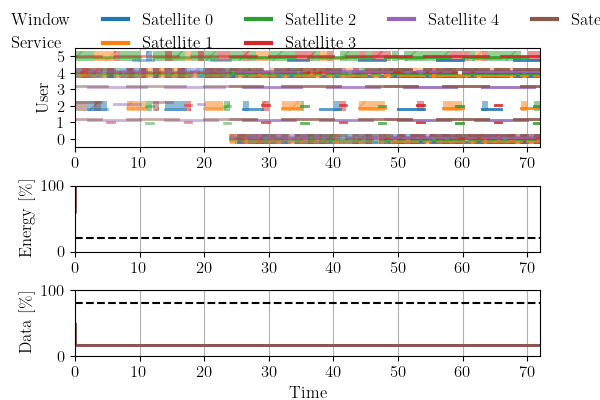

In [18]:
gridspec_kw = dict(hspace=0.5, height_ratios=[1.5, 1, 1])
fig, axs = plt.subplots(3, 1, figsize=(6, 4), gridspec_kw=gridspec_kw)
plotting.plot_requests_service_windows(
    requests, problem.service_windows, policy, ax=axs[0], old_policy=policy
)
plotting.plot_resources(problem, policy, ax=axs[1:])
# plt.tight_layout()
plt.show()

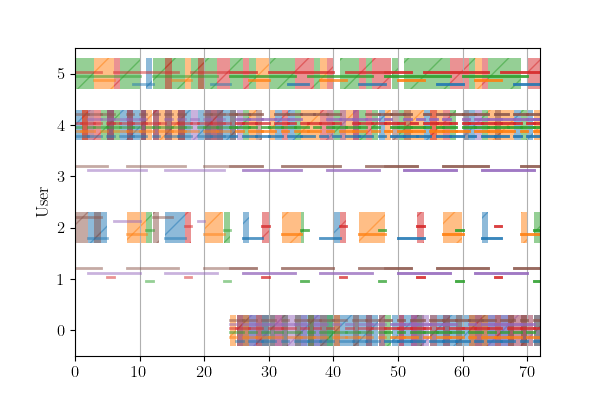

In [19]:
plt.figure(figsize=(6, 4))
ax = plt.gca()
plotting.plot_requests_service_windows(
    requests, service_windows, policy, ax=ax, old_policy=policy
)

# Hyperparameter Search

In [20]:
config = {
    "date": "2022-09-01T00:00:00",
    "duration_factor": 0.40,
    "solver_seed": 0,
    "RB": {},
    "FS": {
        "d": [1, 2, 3, 4],
        "gamma": [0.8, 0.9, 0.99, 1.0],
        "N_max": [2, 5, 10],
        "d_min": [0.5, 1, 2, 5],
    },
    "MCTS": {
        "d": [1, 2, 3, 4],
        "gamma": [0.8, 0.9, 0.99, 1.0],
        "d_min": [0.5, 1, 2, 5],
        "N_max": [5, 10],
        #
        "n": [5, 10, 50],
        "c": [0.1, 1, 10],
    },
    "IP": {
        "time_step_factor": [10],
    },
}
results_all = exp_2.solve_problem(config, n_jobs=1)

NameError: name 'exp_2' is not defined

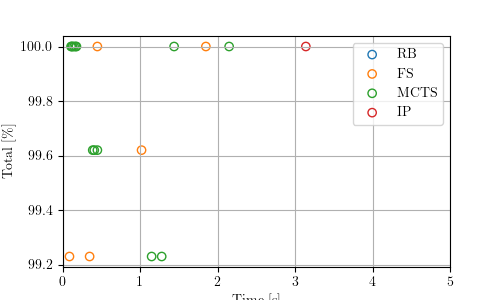

In [ ]:
plt.figure(figsize=(5, 3))
for i, solver in enumerate(["RB", "FS", "MCTS", "IP"]):
    results = results_all[solver]
    total = [r["total"] for r in results if r["total"] > 99]
    time = [r["time"] for r in results if r["total"] > 99]
    plt.scatter(
        time,
        total,
        label=solver,
        marker="o",
        facecolor="None",
        edgecolor=util.TABLEAU_COLORS[i],
    )
plt.xlabel("Time [s]")
plt.ylabel("Total [\\%]")
plt.xlim([0, 5])
plt.grid()
plt.legend()
plt.show()

In [5]:
import plotly.express as px
import pandas as pd

for solver in ["FS", "MCTS", "IP"]:
    df_dict = []
    for r in results_all[solver]:
        tmp = r["params"].copy()
        tmp["total"] = r["total"]
        tmp["time"] = r["time"]
        df_dict.append(tmp)
    df = pd.DataFrame(df_dict)

    fig = px.parallel_coordinates(df, color="total")
    fig.show()

    # Correlation of parameters to total
    correlation = df.corr()
    print(f"\n********** {solver} **********")
    print("\nHyperparameters correlation")
    print(correlation["total"].sort_values())

    # Best parameters
    print("\nBest parameters")
    print(df[df["total"] == df["total"].max()])


********** FS **********

Hyperparameters correlation
N_max   -0.230202
gamma   -0.146384
d_min    0.053344
time     0.170882
d        0.453614
total    1.000000
Name: total, dtype: float64

Best parameters
   d  gamma  N_max  d_min  total  time
0  3   0.99      5    0.5  100.0  0.45
1  3   0.90     10    1.0  100.0  1.85



********** MCTS **********

Hyperparameters correlation
N_max   -0.268849
n       -0.204535
gamma   -0.202371
time     0.015939
c        0.023715
d_min    0.127930
d        0.252400
total    1.000000
Name: total, dtype: float64

Best parameters
   d  gamma  d_min  N_max   n     c  total  time
0  3    0.8    1.0     10   5   1.0  100.0  0.11
1  3    0.8    1.0     10   5   0.1  100.0  0.12
2  3    0.8    1.0     10   5  10.0  100.0  0.13
3  2    0.8    0.5     10   5  10.0  100.0  0.15
4  2    0.8    0.5     10   5   1.0  100.0  0.17
5  2    0.8    0.5     10   5   0.1  100.0  0.18
6  3    0.8    0.5      5  50   1.0  100.0  1.44
7  3    0.9    0.5     10  50  10.0  100.0  2.15



********** IP **********

Hyperparameters correlation
time_step_factor   -0.995609
time                0.951960
total               1.000000
Name: total, dtype: float64

Best parameters
   time_step_factor  total  time
0                 4  100.0  3.14


# Monte-Carlo Sims

In [134]:
base_config = {
    "date": "2022-{month:02d}-01T00:00:00",
    "duration_factor": None,
    "solver_seed": 0,
    "RB": {},
    "FS": {
        "d": [1, 2, 3],
        "gamma": [0.7, 0.8, 0.9, 0.99],
        "N_max": [5, 10],
        "d_min": [0.5, 1, 2],
    },
    "MCTS": {
        "d": [1, 2, 3],
        "gamma": [0.7, 0.8, 0.9, 0.99],
        "d_min": [0.5, 1, 2],
        "n": [5, 10, 50],
        "c": [0.1, 1, 10],
        "N_max": [5, 10],
    },
    "IP": {
        "time_step_factor": [2, 3, 4, 5, 10],
    },
}

In [135]:
months = np.arange(1, 11)
duration_factors = np.linspace(0.3, 0.39, 10).round(2)

results_tmp = []
for duration_factor in duration_factors:
    print(f"Duration factor: {duration_factor}")
    for month in months:
        print(f"Month: {month}")

        # Update config
        config = base_config.copy()
        config["date"] = config["date"].format(month=month)
        config["duration_factor"] = duration_factor

        # Solve problem
        res = experiment_1.solve_problem(config, n_jobs=5)

        # Store results
        for solver, res_solver in res.items():
            for r in res_solver:
                tmp = r.copy()
                tmp["params"] = str(r["params"])
                tmp["solver"] = solver
                tmp["duration_factor"] = duration_factor
                tmp["month"] = month
                results_tmp.append(tmp)

results_df = pd.DataFrame(results_tmp)

Duration factor: 0.3
Month: 1
Month: 2
Month: 3
Month: 4
Month: 5
Month: 6
Month: 7
Month: 8
Month: 9
Month: 10
Duration factor: 0.31
Month: 1
Month: 2
Month: 3
Month: 4
Month: 5
Month: 6
Month: 7
Month: 8
Month: 9
Month: 10
Duration factor: 0.32
Month: 1
Month: 2
Month: 3
Month: 4
Month: 5
Month: 6
Month: 7
Month: 8
Month: 9
Month: 10
Duration factor: 0.33
Month: 1
Month: 2
Month: 3
Month: 4
Month: 5
Month: 6
Month: 7
Month: 8
Month: 9
Month: 10
Duration factor: 0.34
Month: 1
Month: 2
Month: 3
Month: 4
Month: 5
Month: 6
Month: 7
Month: 8
Month: 9
Month: 10
Duration factor: 0.35
Month: 1
Month: 2
Month: 3
Month: 4
Month: 5
Month: 6
Month: 7
Month: 8
Month: 9
Month: 10
Duration factor: 0.36
Month: 1
Month: 2
Month: 3
Month: 4
Month: 5
Month: 6
Month: 7
Month: 8
Month: 9
Month: 10
Duration factor: 0.37
Month: 1
Month: 2
Month: 3
Month: 4
Month: 5
Month: 6
Month: 7
Month: 8
Month: 9
Month: 10
Duration factor: 0.38
Month: 1
Month: 2
Month: 3
Month: 4
Month: 5
Month: 6
Month: 7
Month: 8
Mon

In [139]:
results_df.head()

,total,user,reward,time,params,solver,duration_factor,month
0,95.79,"[100.0, 100.0, 100.0, 80.0, 100.0, 100.0]",17.28,0.00,{},RB,0.3,1
1,100.00,"[100.0, 100.0, 100.0, 100.0, 100.0, 100.0]",18.52,0.03,"{'d': 2, 'gamma': 0.7, 'N_max': 5, 'd_min': 2}",FS,0.3,1
2,100.00,"[100.0, 100.0, 100.0, 100.0, 100.0, 100.0]",18.36,0.03,"{'d': 2, 'gamma': 0.8, 'N_max': 5, 'd_min': 2}",FS,0.3,1
3,100.00,"[100.0, 100.0, 100.0, 100.0, 100.0, 100.0]",18.27,0.03,"{'d': 2, 'gamma': 0.9, 'N_max': 5, 'd_min': 2}",FS,0.3,1
4,100.00,"[100.0, 100.0, 100.0, 100.0, 100.0, 100.0]",18.18,0.04,"{'d': 2, 'gamma': 0.7, 'N_max': 5, 'd_min': 1}",FS,0.3,1


In [164]:
for dur in duration_factors:
    df = results_df
    df = df[results_df["duration_factor"] == dur]
    df = df.drop(columns=["user", "month", "duration_factor"])
    df = df.groupby(["solver", "params"])

    # Mean within each group
    df = df.mean().reset_index()

    # Keep those with the highest total
    df = df[df["total"] == df.groupby("solver")["total"].transform("max")]

    # # Keep one for each solver
    # df = df.groupby("solver")

    # Order RB, FS, MCTS, IP
    df["solver"] = pd.Categorical(df["solver"], ["RB", "FS", "MCTS", "IP"])
    df = df.sort_values("solver")

    print(f"\n********** Duration factor: {dur} **********")
    print(df.to_string())


********** Duration factor: 0.3 **********
    solver                                                               params    total  reward   time
725     RB                                                                   {}   97.634  17.660  0.000
70      FS                      {'d': 3, 'gamma': 0.99, 'N_max': 5, 'd_min': 1}  100.000  18.315  0.194
66      FS                   {'d': 3, 'gamma': 0.99, 'N_max': 10, 'd_min': 0.5}  100.000  18.253  2.453
65      FS                       {'d': 3, 'gamma': 0.9, 'N_max': 5, 'd_min': 2}  100.000  18.262  0.149
64      FS                       {'d': 3, 'gamma': 0.9, 'N_max': 5, 'd_min': 1}  100.000  18.262  0.213
62      FS                      {'d': 3, 'gamma': 0.9, 'N_max': 10, 'd_min': 2}  100.000  18.228  1.010
61      FS                      {'d': 3, 'gamma': 0.9, 'N_max': 10, 'd_min': 1}  100.000  18.233  1.602
59      FS                       {'d': 3, 'gamma': 0.8, 'N_max': 5, 'd_min': 2}  100.000  18.220  0.145
56      FS          

In [181]:
duration_factor = 0.36

# Print mean and std for each solver (best parameters)
df = results_df
df = df[results_df["duration_factor"] == duration_factor]
df = df.drop(columns=["user", "month", "duration_factor"])
df = df.groupby(["solver", "params"])

# Mean within each group
df_mean = df.mean().reset_index()
df_std = df.std().reset_index()

# Merge mean and std
df = df_mean.merge(df_std, on=["solver", "params"], suffixes=("_mean", "_std"))

# Keep those with the highest total
df = df[df["total_mean"] == df.groupby("solver")["total_mean"].transform("max")]

# Keep one for each solver (the one with the lowest time)
df = df[df["time_mean"] == df.groupby("solver")["time_mean"].transform("min")]

# Order RB, FS, MCTS, IP
df["solver"] = pd.Categorical(df["solver"], ["RB", "FS", "MCTS", "IP"])
df = df.sort_values("solver")

print(f"\n********** Duration factor: {duration_factor} **********")
print(df.to_string())


********** Duration factor: 0.36 **********
    solver                                                            params  total_mean  reward_mean  time_mean  total_std  reward_std  time_std
725     RB                                                                {}      86.890       19.018      0.000   6.490549    1.552624  0.000000
64      FS                    {'d': 3, 'gamma': 0.9, 'N_max': 5, 'd_min': 1}      99.957       22.092      0.227   0.135978    0.560849  0.008233
541   MCTS  {'d': 3, 'gamma': 0.7, 'd_min': 1, 'n': 50, 'c': 1, 'N_max': 10}     100.000       22.060      0.716   0.000000    0.529801  0.035653
75      IP                                           {'time_step_factor': 4}     100.000       22.894      3.307   0.000000    0.764464  0.029078


In [180]:
# Convert the previous df to latex rounding to two significant digits and formatting with mean (std)
df_latex = df.copy()
df_latex.drop(columns=["params"], inplace=True)

# Append MCTS (solver is categorical)
df_latex["total"] = (
    df_latex["total_mean"].apply(lambda x: f"{x:0.2f}")
    + " ("
    + df_latex["total_std"].apply(lambda x: f"{x:0.2f}")
    + ")"
)
df_latex["reward"] = (
    df_latex["reward_mean"].apply(lambda x: f"{x:0.2f}")
    + " ("
    + df_latex["reward_std"].apply(lambda x: f"{x:0.2f}")
    + ")"
)
df_latex["time"] = (
    df_latex["time_mean"].apply(lambda x: f"{x:0.2f}")
    + " ("
    + df_latex["time_std"].apply(lambda x: f"{x:0.2f}")
    + ")"
)
df_latex.drop(
    columns=[
        "total_mean",
        "total_std",
        "reward_mean",
        "reward_std",
        "time_mean",
        "time_std",
    ],
    inplace=True,
)
print(df_latex.to_latex(index=False))

\begin{tabular}{llll}
\toprule
solver & total & reward & time \\
\midrule
RB & 86.89 (6.49) & 19.02 (1.55) & 0.00 (0.00) \\
FS & 99.96 (0.14) & 22.09 (0.56) & 0.23 (0.01) \\
MCTS & 100.00 (0.00) & 22.06 (0.53) & 0.72 (0.04) \\
IP & 100.00 (0.00) & 22.89 (0.76) & 3.31 (0.03) \\
\bottomrule
\end{tabular}



In [187]:
import pathfinder_data

date = config["date"].format(month=1)
problem = experiment_1.get_problem(date, duration_factor)
users = [u["desc"] for u in pathfinder_data.users.copy()]
durs = [v.duration for v in problem.request_dict.values() if v.id >= 0]
{u: d for u, d in zip(users, durs)}

{'Low Lunar Orbit (LLO) mission': 3.0,
 'Surface operations': 5.5,
 'Autonomous Rover': 5.5,
 'Tele-Operated Rover': 5.0,
 'CubeSat on PCO': 3.0,
 'Lander on the North Pole': 0.5}